# Phase 6 - Model Evaluation

In [1]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [2]:
def evaluate_phase6(model, history, model_name, X_test_padded, y_test, X_test_reviews, output_dir="phase6_results"):

    # output folder
    model_dir = os.path.join(output_dir, model_name.replace(" ", "_"))

    os.makedirs(model_dir, exist_ok=True)

    # input shape
    print("\n" + "=" * 60)
    print(f"PHASE 6 - {model_name}")
    print("=" * 60)

    print("Model input shape :", X_test_padded.shape)
    print("Test labels shape :", np.asarray(y_test).shape)
    print("Test reviews shape:", np.asarray(X_test_reviews).shape)

    # Make sure all lengths match
    if len(X_test_padded) != len(y_test):
        raise ValueError(
            "X_test_padded and y_test have different lengths."
        )

    if len(X_test_reviews) != len(y_test):
        raise ValueError(
            "X_test_reviews and y_test have different lengths."
        )

    
    # predictions
    probabilities = model.predict(X_test_padded, batch_size=128, verbose=1).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    print("\nPrediction shape:", probabilities.shape)

    # metrics
    accuracy = accuracy_score(y_test, predictions)
    precision_value = precision_score(y_test, predictions, zero_division=0)
    recall_value = recall_score(y_test, predictions, zero_division=0)
    f1_value = f1_score(y_test, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_test, probabilities)
    average_precision = average_precision_score(y_test, probabilities)

    # confusion matrix
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    print("\n")
    print(f"{model_name} RESULTS")
    print("\n")


    print(f"Accuracy          : {accuracy:.5f}")
    print(f"Precision         : {precision_value:.5f}")
    print(f"Recall            : {recall_value:.5f}")
    print(f"F1 Score          : {f1_value:.5f}")
    print(f"ROC-AUC           : {roc_auc:.5f}")
    print(f"Average Precision : {average_precision:.5f}")

    print("\nConfusion Matrix")
    print("-" * 40)
    print(cm)

    print("\nTN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    
    # training vs val accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join( model_dir,"training_validation_accuracy.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    
    # training vs validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig( os.path.join(model_dir, "training_validation_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"]).plot(ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix")
    plt.savefig(os.path.join(model_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # roc curve
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(model_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # precision recall curve
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, probabilities)
    plt.figure(figsize=(8, 6))
    plt.plot(pr_recall, pr_precision, label=f"{model_name} (AP = {average_precision:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(model_dir, "precision_recall_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Miss classified reviews
    
    y_test_array = np.asarray(y_test).reshape(-1)
    reviews_array = np.asarray(X_test_reviews).reshape(-1)
    misclassified_mask = (y_test_array != predictions)

    misclassified = pd.DataFrame({
        "review": reviews_array,
        "actual": y_test_array,
        "predicted": predictions,
        "probability": probabilities
    })

    misclassified = misclassified[misclassified_mask].reset_index(drop=True)
    misclassified["actual_sentiment"] = (misclassified["actual"].map({
            0: "Negative",
            1: "Positive"
        })
    )

    misclassified["predicted_sentiment"] = (misclassified["predicted"]
        .map({
            0: "Negative",
            1: "Positive"
        })
    )

    # save missclassified reviews
    misclassified.to_csv(os.path.join(model_dir, "misclassified_reviews.csv"), index=False)
    print("\nTotal misclassified:",len(misclassified))

    # missclassified counts
    false_positive_count = np.sum((y_test_array == 0) & (predictions == 1))
    false_negative_count = np.sum((y_test_array == 1) & (predictions == 0))
    print("False Positives:", false_positive_count)
    print("False Negatives:", false_negative_count)

    # visual for misclassifyy
    plt.figure(figsize=(7, 5))
    values = [false_positive_count, false_negative_count]
    labels = ["False Positive", "False Negative"]
    plt.bar( labels, values)
    plt.title(f"{model_name} - Misclassified Reviews")
    plt.xlabel( "Error Type")
    plt.ylabel("Number of Reviews")
    for i, value in enumerate(values):
        plt.text(
            i,
            value + 5,
            str(value),
            ha="center"
        )
    plt.grid(axis="y")
    plt.savefig(os.path.join(model_dir, "misclassified_reviews.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # dis sample missclasssified reviews
    print("\nSample Misclassified Reviews")
    print("-" * 60)

    display(
        misclassified[
            [
                "review",
                "actual_sentiment",
                "predicted_sentiment",
                "probability"
            ]
        ].head(10)
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc,
        "Average Precision": average_precision,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
        "Misclassified": len(misclassified),
        "Confusion Matrix": cm,
        "Probabilities": probabilities,
        "Predictions": predictions,
        "Misclassified Reviews": misclassified
    }

### ANN

In [3]:
processed_df = pd.read_csv("processed_data/imdb_cleaned.csv")

In [4]:
from sklearn.model_selection import train_test_split

X = processed_df["clean_review"]
y = processed_df["label"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val_text, X_test_reviews, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_test_reviews:", X_test_reviews.shape)
print("y_test:", y_test.shape)

X_test_reviews: (5000,)
y_test: (5000,)


In [5]:
import pickle

with open("processed_data/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 85744


In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test_seq = tokenizer.texts_to_sequences(
    X_test_reviews
)

X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=200,
    padding="post",
    truncating="post"
)

print("X_test_padded:", X_test_padded.shape)

X_test_padded: (5000, 200)


## 1.ANN

In [8]:
ann_model = tf.keras.models.load_model("models/ann_model.keras")
ann_history = pd.read_csv("history/best_ann_batch128_training_history (1).csv")


PHASE 6 - ANN Batch 128
Model input shape : (5000, 200)
Test labels shape : (5000,)
Test reviews shape: (5000,)
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Prediction shape: (5000,)


ANN Batch 128 RESULTS


Accuracy          : 0.49220
Precision         : 0.49278
Recall            : 0.53200
F1 Score          : 0.51164
ROC-AUC           : 0.48264
Average Precision : 0.47851

Confusion Matrix
----------------------------------------
[[1131 1369]
 [1170 1330]]

TN: 1131
FP: 1369
FN: 1170
TP: 1330


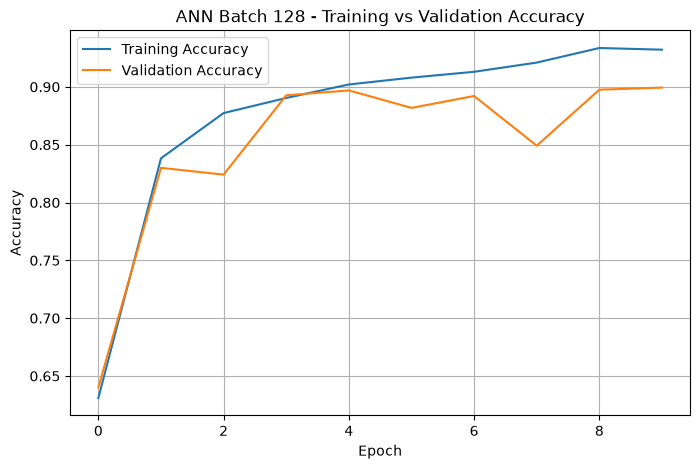

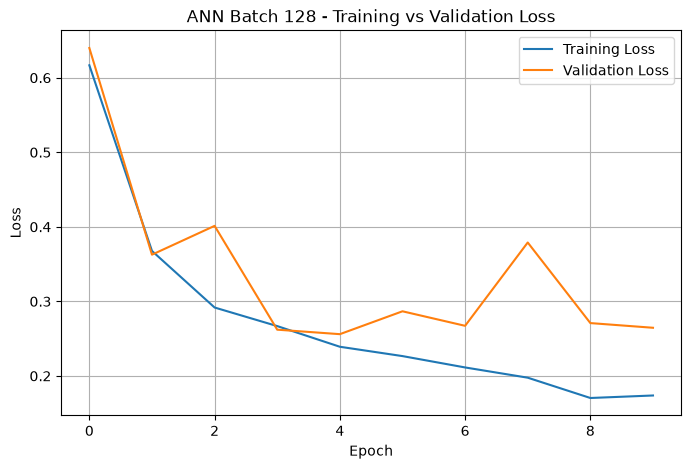

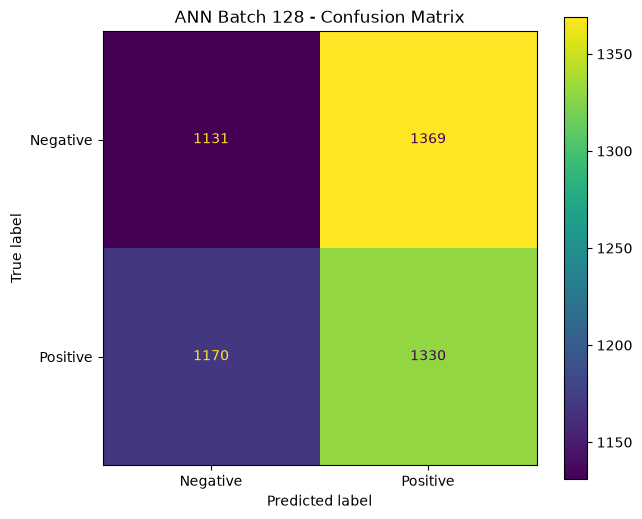

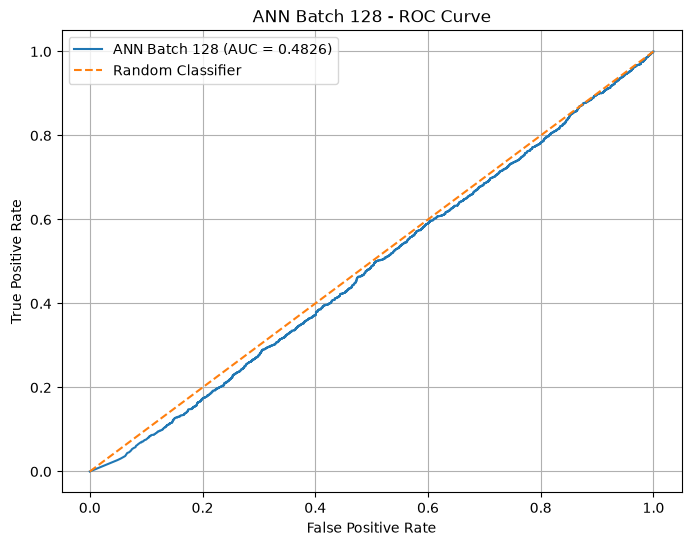

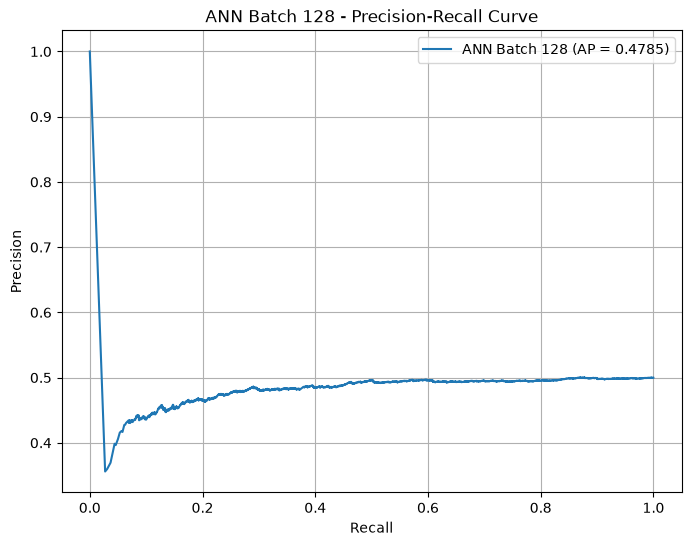


Total misclassified: 2539
False Positives: 1369
False Negatives: 1170


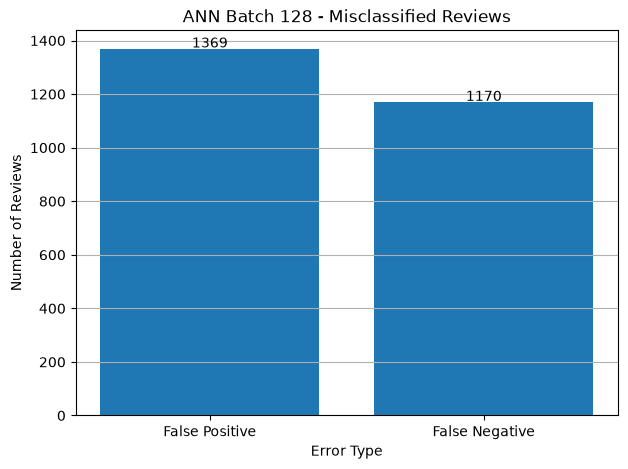


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,although it has been years i still remember th...,Negative,Positive,5.648323e-01
1,warning this review will reveal the ending of ...,Negative,Positive,8.704073e-01
2,this is a film that has garnered any interest ...,Negative,Positive,9.994227e-01
3,where should i begin with this movie all i kno...,Negative,Positive,9.999891e-01
4,pendragon pictures new film h g wells war of t...,Positive,Negative,3.139292e-08
5,i went to this film having no idea what to exp...,Positive,Negative,4.251290e-10
6,the sounds in the movie were so mundane and ri...,Negative,Positive,1.000000e+00
7,this is a strong movie from a historical and e...,Positive,Negative,4.892931e-02
8,i love watching australian movies but this ste...,Negative,Positive,8.175655e-01
9,this is the fourth full length feature film by...,Positive,Negative,1.270576e-06


In [9]:
ann_results = evaluate_phase6(
    model=ann_model,
    history=ann_history,
    model_name="ANN Batch 128",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [10]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{ann_results[key]:.5f}")

Accuracy            : 0.49220
Precision           : 0.49278
Recall              : 0.53200
F1 Score            : 0.51164
ROC-AUC             : 0.48264
Average Precision   : 0.47851


## 2. RNN

In [11]:
rnn_model = tf.keras.models.load_model("models/optimized_RNN.keras")
rnn_history = pd.read_csv("history/rnn_batch128_training_history.csv")



PHASE 6 - RNN Batch 128
Model input shape : (5000, 200)
Test labels shape : (5000,)
Test reviews shape: (5000,)
 1/40 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step

I0000 00:00:1787729246.030785  247553 service.cc:153] XLA service 0xaefb43500 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787729246.030797  247553 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1787729246.045451  247553 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1787729246.129112  249490 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1787729246.178266  247553 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Prediction shape: (5000,)


RNN Batch 128 RESULTS


Accuracy          : 0.50320
Precision         : 0.50528
Recall            : 0.30640
F1 Score          : 0.38147
ROC-AUC           : 0.50102
Average Precision : 0.49702

Confusion Matrix
----------------------------------------
[[1750  750]
 [1734  766]]

TN: 1750
FP: 750
FN: 1734
TP: 766


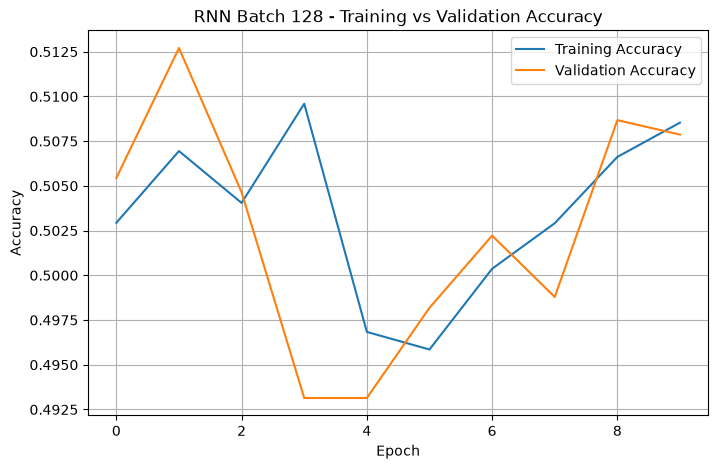

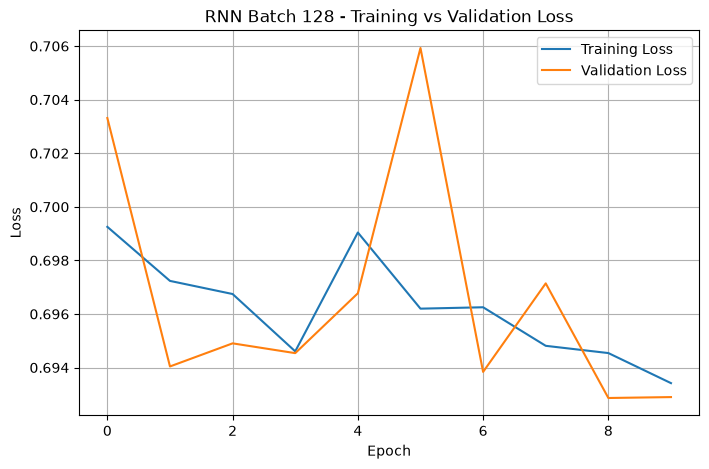

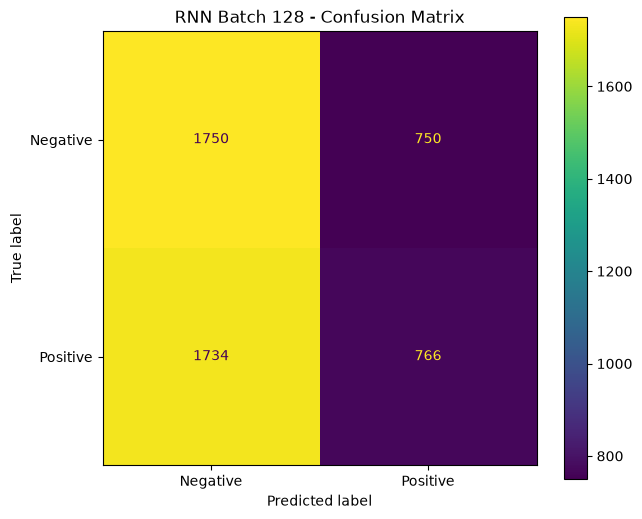

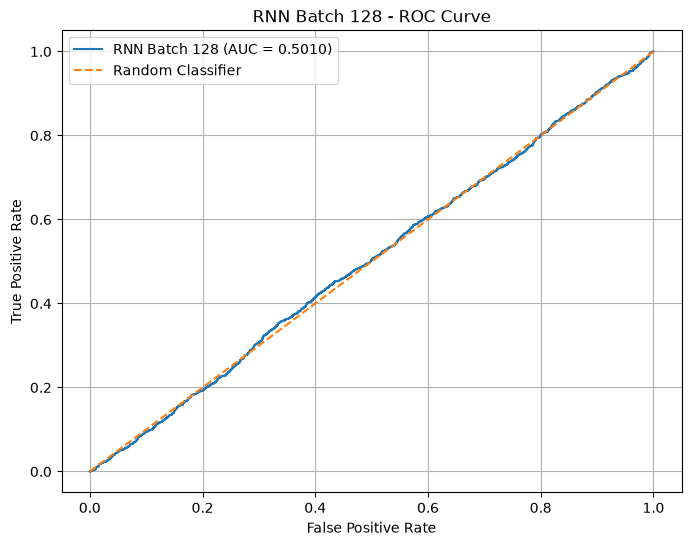

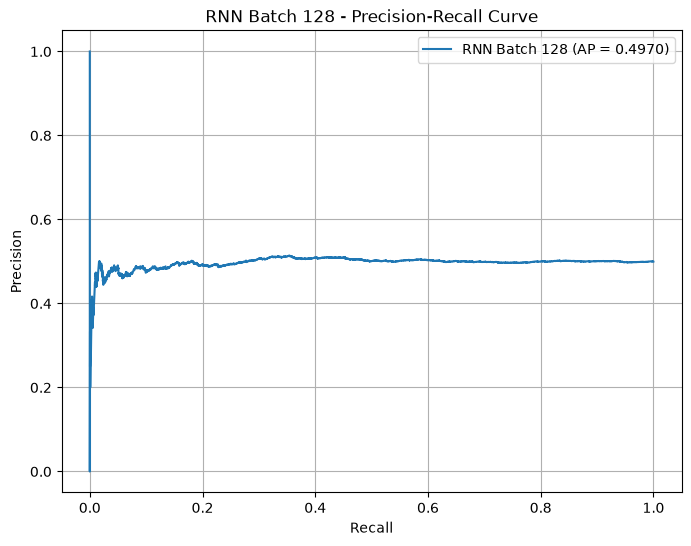


Total misclassified: 2484
False Positives: 750
False Negatives: 1734


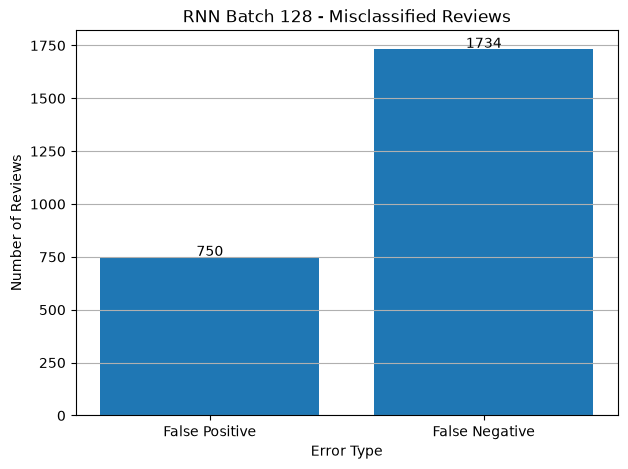


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,although it has been years i still remember th...,Negative,Positive,0.502700
1,the blob is a great horror movie not merely be...,Positive,Negative,0.490141
2,the saddest thing about this film is that only...,Positive,Negative,0.472407
3,gene hackman is a former marine corps colonel ...,Negative,Positive,0.526309
4,there are spoilers but trust me i m doing you ...,Negative,Positive,0.509459
5,pendragon pictures new film h g wells war of t...,Positive,Negative,0.492983
6,i loved this show growing up and i still watch...,Positive,Negative,0.494901
7,creative use of modern and mystical elements c...,Positive,Negative,0.496166
8,my kasi lemmings certainly is a fair looking w...,Positive,Negative,0.492884
9,i went to this film having no idea what to exp...,Positive,Negative,0.497351


In [12]:
rnn_results = evaluate_phase6(
    model=rnn_model,
    history=rnn_history,
    model_name="RNN Batch 128",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [13]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{rnn_results[key]:.5f}")

Accuracy            : 0.50320
Precision           : 0.50528
Recall              : 0.30640
F1 Score            : 0.38147
ROC-AUC             : 0.50102
Average Precision   : 0.49702


## 3. LSTM

In [14]:
lstm_model = tf.keras.models.load_model("models/optimized_lstm.keras")

with open("history/lstm_reducelr_history.pkl", "rb") as f:
    lstm_history = pickle.load(f)


PHASE 6 - LSTM ReduceLR
Model input shape : (5000, 200)
Test labels shape : (5000,)
Test reviews shape: (5000,)
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step

Prediction shape: (5000,)


LSTM ReduceLR RESULTS


Accuracy          : 0.82760
Precision         : 0.85363
Recall            : 0.79080
F1 Score          : 0.82101
ROC-AUC           : 0.87008
Average Precision : 0.85768

Confusion Matrix
----------------------------------------
[[2161  339]
 [ 523 1977]]

TN: 2161
FP: 339
FN: 523
TP: 1977


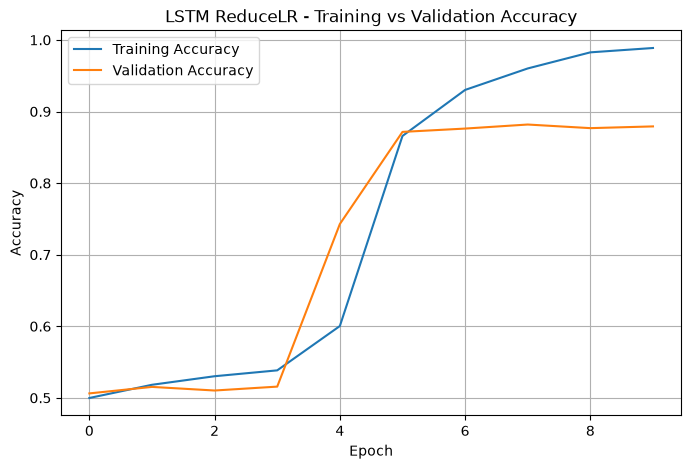

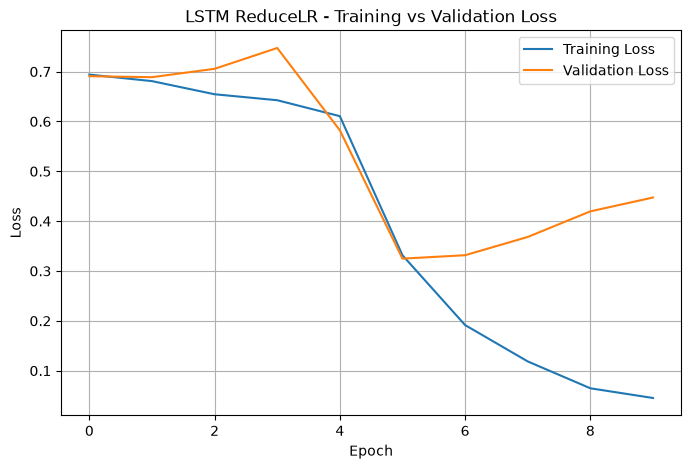

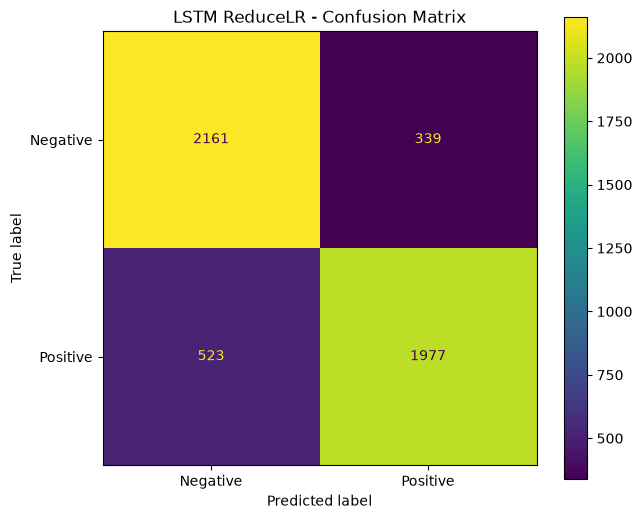

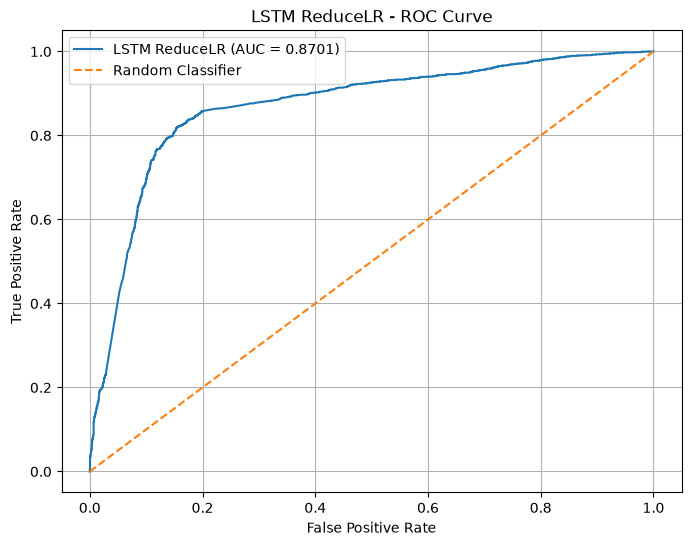

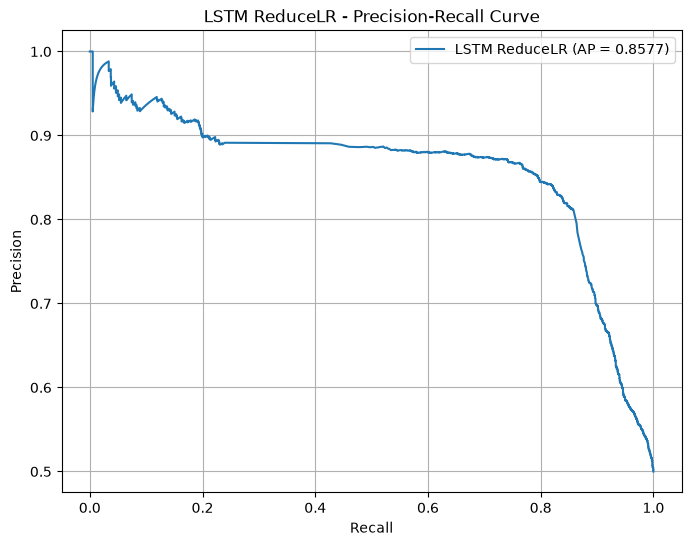


Total misclassified: 862
False Positives: 339
False Negatives: 523


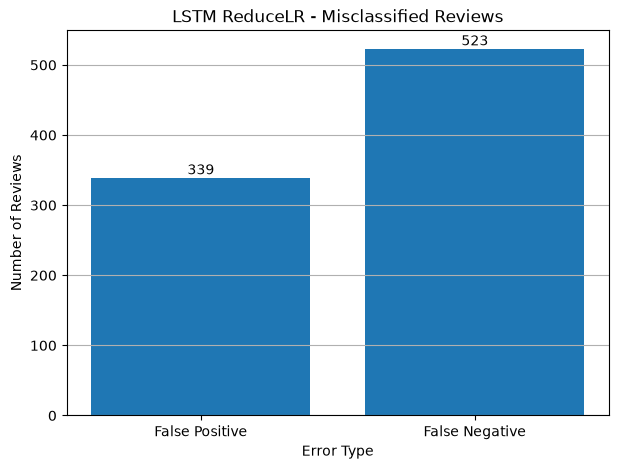


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,if this movie had a point i never discovered i...,Negative,Positive,0.585199
1,this movie is pretty cheesy but i do give it c...,Positive,Negative,0.196365
2,one word for it hilarious i haven t watched at...,Positive,Negative,0.196352
3,i loved this film fantastically original and d...,Positive,Negative,0.394749
4,when i saw this movie in the theater when it c...,Positive,Negative,0.157190
5,we re talking about a low budget film and it s...,Positive,Negative,0.196365
6,what the movie the s really represents to thos...,Positive,Negative,0.093301
7,i can imagine what happened for this film to c...,Negative,Positive,0.823941
8,i read a lot of high hopes from readers of the...,Negative,Positive,0.583586
9,hollywood had a long love affair with bogus ar...,Negative,Positive,0.846751


In [15]:
lstm_results = evaluate_phase6(
    model=lstm_model,
    history=lstm_history,
    model_name="LSTM ReduceLR",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [16]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{lstm_results[key]:.5f}")

Accuracy            : 0.82760
Precision           : 0.85363
Recall              : 0.79080
F1 Score            : 0.82101
ROC-AUC             : 0.87008
Average Precision   : 0.85768


## 4. Bi-LSTM

In [17]:
bilstm_model = tf.keras.models.load_model("models/optimized_BiLSTM.keras")
bilstm_history = pd.read_csv("history/bilstm_rmsprop_training_history.csv")


PHASE 6 - Bi-LSTM RMSprop
Model input shape : (5000, 200)
Test labels shape : (5000,)
Test reviews shape: (5000,)
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step

Prediction shape: (5000,)


Bi-LSTM RMSprop RESULTS


Accuracy          : 0.86360
Precision         : 0.85425
Recall            : 0.87680
F1 Score          : 0.86538
ROC-AUC           : 0.93489
Average Precision : 0.92749

Confusion Matrix
----------------------------------------
[[2126  374]
 [ 308 2192]]

TN: 2126
FP: 374
FN: 308
TP: 2192


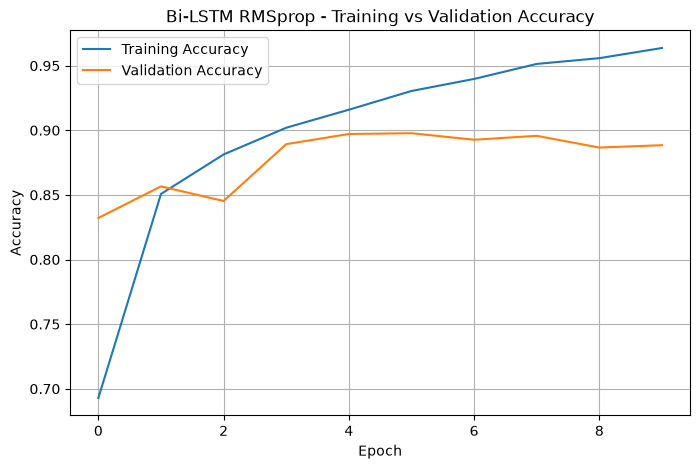

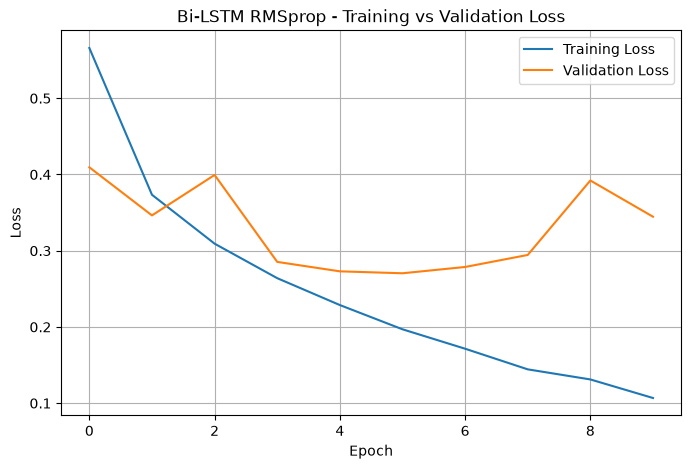

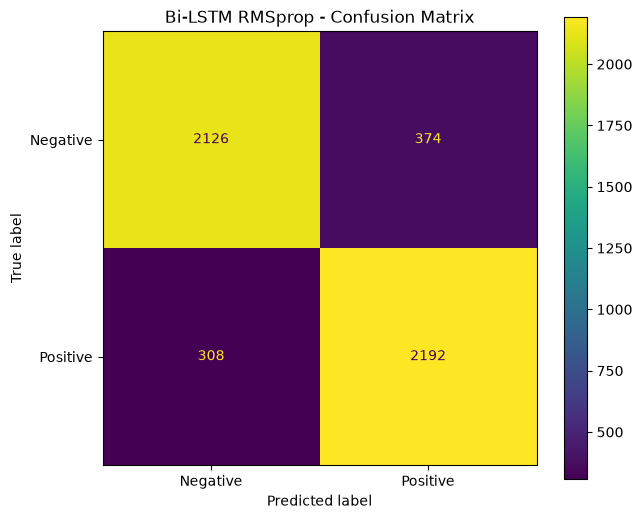

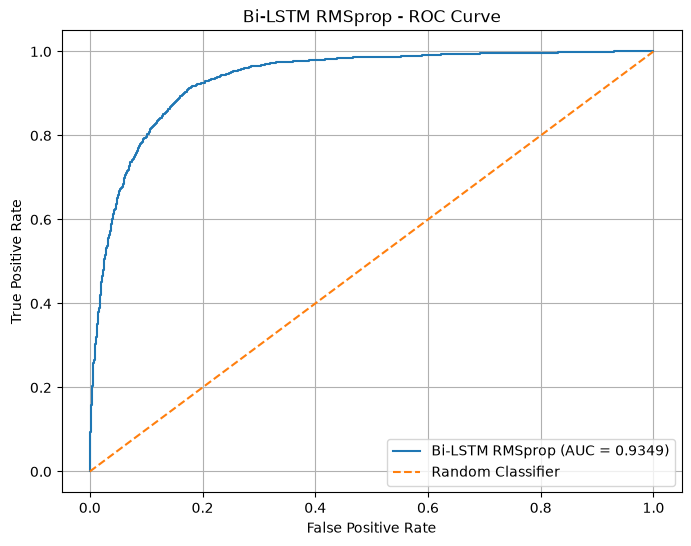

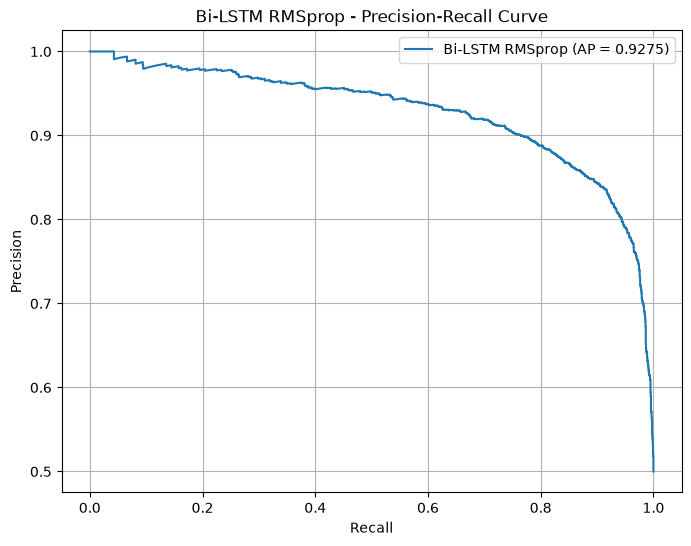


Total misclassified: 682
False Positives: 374
False Negatives: 308


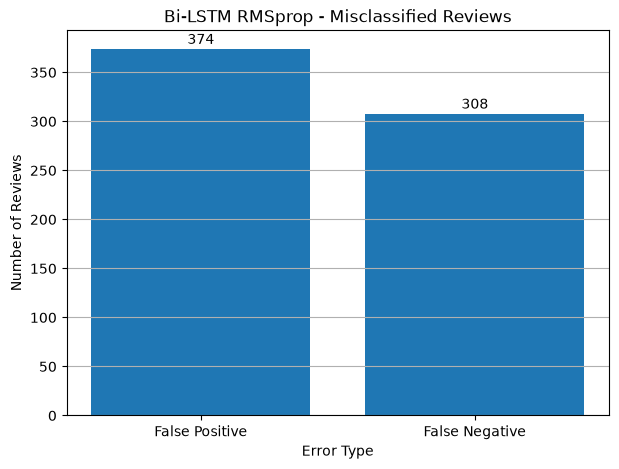


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,if this movie had a point i never discovered i...,Negative,Positive,0.740619
1,i loved this film fantastically original and d...,Positive,Negative,0.379581
2,when i saw this movie in the theater when it c...,Positive,Negative,0.201795
3,i can imagine what happened for this film to c...,Negative,Positive,0.536033
4,after reading the terrible reviews of this mov...,Positive,Negative,0.352150
5,hollywood had a long love affair with bogus ar...,Negative,Positive,0.910135
6,this is what happens when you try to adapt a p...,Negative,Positive,0.716149
7,i couldn t help but relish the entire premise ...,Positive,Negative,0.471490
8,michael feifer writes and directs this fictiti...,Negative,Positive,0.832961
9,some people have made a point of dissing this ...,Negative,Positive,0.870383


In [18]:
bilstm_results = evaluate_phase6(
    model=bilstm_model,
    history=bilstm_history,
    model_name="Bi-LSTM RMSprop",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [19]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{bilstm_results[key]:.5f}")

Accuracy            : 0.86360
Precision           : 0.85425
Recall              : 0.87680
F1 Score            : 0.86538
ROC-AUC             : 0.93489
Average Precision   : 0.92749


## 5. GRU

In [20]:
gru_model = tf.keras.models.load_model("models/optimized_GRU.keras")
gru_history = pd.read_csv("history/best_GRU_training_history.csv")


PHASE 6 - GRU LR
Model input shape : (5000, 200)
Test labels shape : (5000,)
Test reviews shape: (5000,)
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Prediction shape: (5000,)


GRU LR RESULTS


Accuracy          : 0.85460
Precision         : 0.88729
Recall            : 0.81240
F1 Score          : 0.84819
ROC-AUC           : 0.92862
Average Precision : 0.92080

Confusion Matrix
----------------------------------------
[[2242  258]
 [ 469 2031]]

TN: 2242
FP: 258
FN: 469
TP: 2031


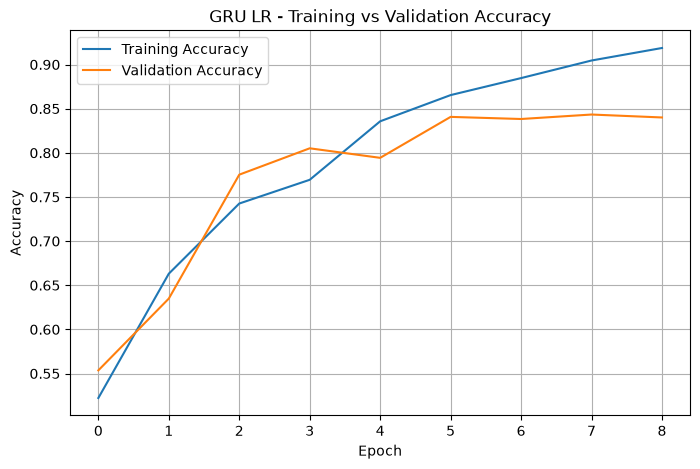

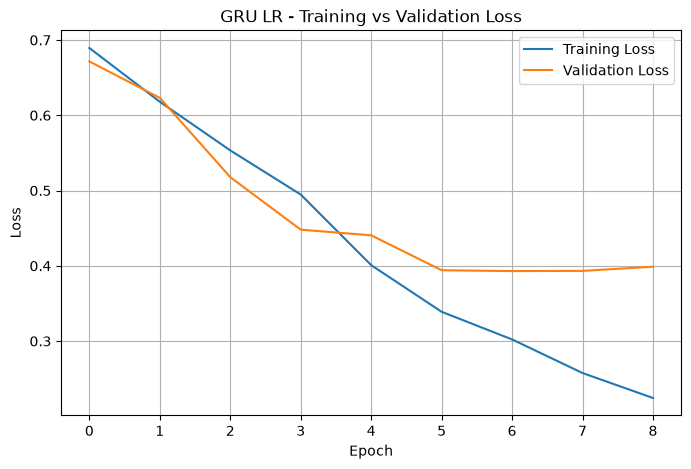

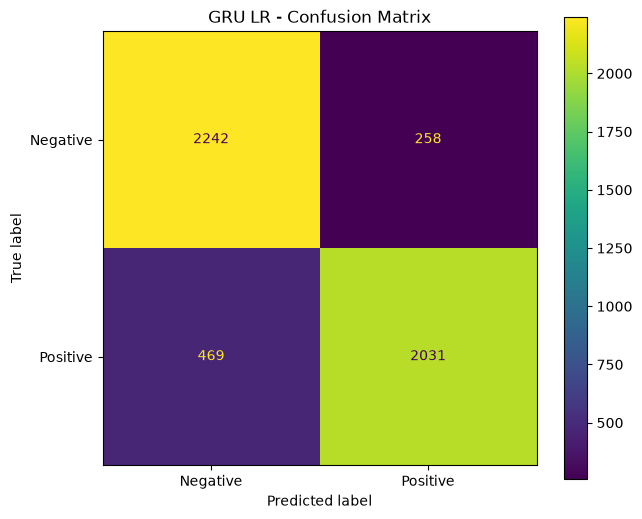

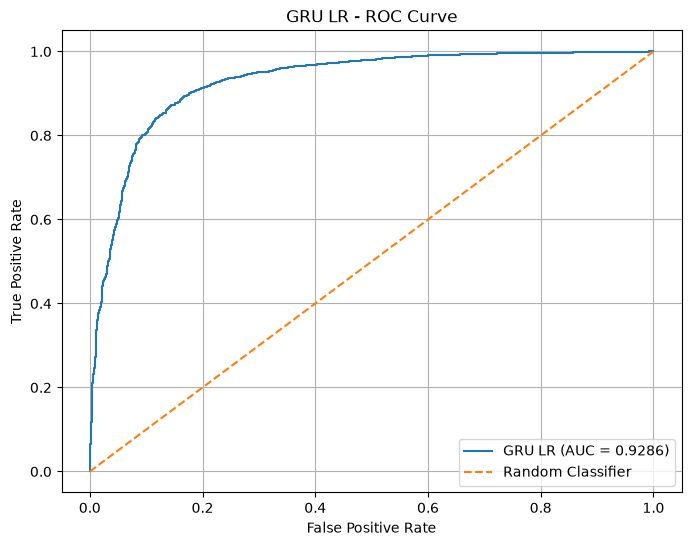

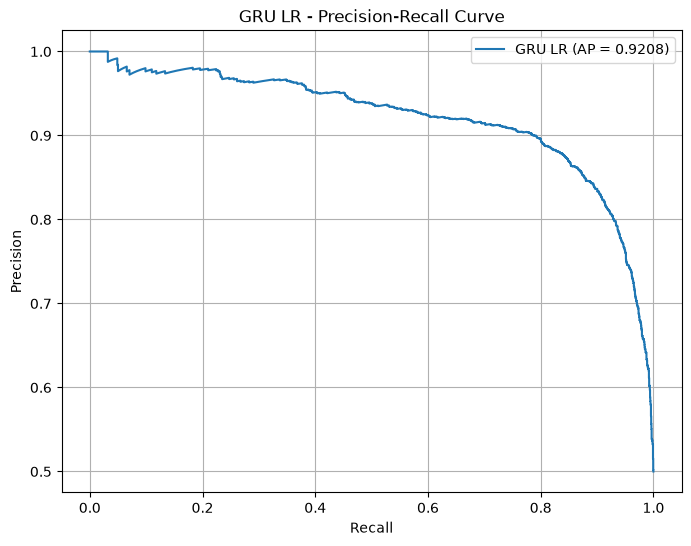


Total misclassified: 727
False Positives: 258
False Negatives: 469


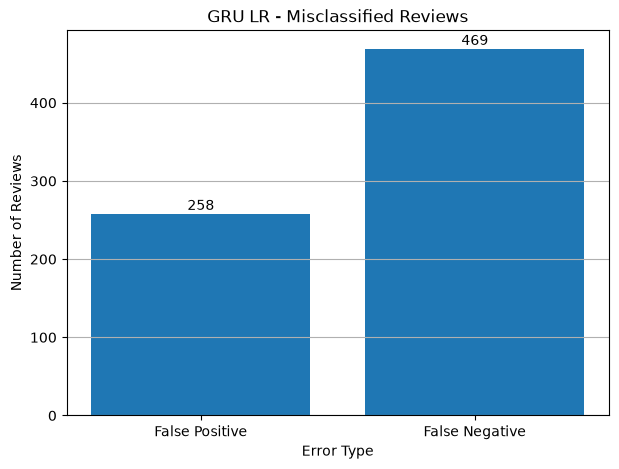


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,the blob is a great horror movie not merely be...,Positive,Negative,0.256602
1,this movie is pretty cheesy but i do give it c...,Positive,Negative,0.422634
2,one word for it hilarious i haven t watched at...,Positive,Negative,0.286155
3,i loved this film fantastically original and d...,Positive,Negative,0.085209
4,we re talking about a low budget film and it s...,Positive,Negative,0.140743
5,what the movie the s really represents to thos...,Positive,Negative,0.010584
6,john huston finished his remarkable career wit...,Positive,Negative,0.470374
7,this may be a bit on the spoilerish side i wou...,Negative,Positive,0.614273
8,i couldn t help but relish the entire premise ...,Positive,Negative,0.363807
9,i have to admit that i went into fever pitch w...,Positive,Negative,0.158250


In [23]:
gru_results = evaluate_phase6(
    model=gru_model,
    history=gru_history,
    model_name="GRU LR",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [27]:
# store all
phase6_results = [

    {
        "Model": "GRU",
        "Accuracy":  0.85460,
        "Precision": 0.88729,
        "Recall": 0.81240,
        "F1 Score": 0.84819,
        "ROC-AUC": 0.92862,
        "Average Precision": 0.92080
    },
    

    {
        "Model": "ANN",
        "Accuracy": 0.49220,
        "Precision": 0.49278,
        "Recall": 0.53200,
        "F1 Score": 0.51164,
        "ROC-AUC": 0.48264,
        "Average Precision": 0.47851
    },

    {
        "Model": "Bi-LSTM",
        "Accuracy": 0.86360,
        "Precision": 0.85425,
        "Recall": 0.87680,
        "F1 Score": 0.89493,
        "ROC-AUC": 0.93489,
        "Average Precision": 0.92749
    },



    {
        "Model": "LSTM",
        "Accuracy": 0.82760,
        "Precision": 0.85363,
        "Recall": 0.79080,
        "F1 Score":  0.82101,
        "ROC-AUC": 0.87008,
        "Average Precision": 0.85768
    },



    {
        "Model": "RNN",
        "Accuracy": 0.50320,
        "Precision": 0.50528,
        "Recall": 0.30640,
        "F1 Score": 0.38147,
        "ROC-AUC": 0.50102,
        "Average Precision":0.49702
    }
]


In [28]:
phase6_df = pd.DataFrame(phase6_results)
phase6_results = phase6_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
phase6_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Bi-LSTM,0.8636,0.85425,0.8768,0.89493,0.93489,0.92749
1,GRU,0.8546,0.88729,0.8124,0.84819,0.92862,0.92080
2,LSTM,0.8276,0.85363,0.7908,0.82101,0.87008,0.85768
3,RNN,0.5032,0.50528,0.3064,0.38147,0.50102,0.49702
4,ANN,0.4922,0.49278,0.5320,0.51164,0.48264,0.47851


In [30]:
phase6_results.to_csv("models/final_model_comparison.csv", index=False)
print("saved")

saved
